# Probe — is a scored IR band family motif-local?

**Date:** 2026-08-26 · **Plan:** 02 (coupled-cluster anharmonic IR) · **Status:** screening probe, not evidence for a band position

## The question

Plan 03 (idea 1) rests on a hypothesis: the IR bands that matter are carried by *local* pieces of the
molecule — an edge CH group, a bay, a five-ring — so they can be computed on a small fragment and
transferred to a large one. The same question, asked in the language of latent dimension, is: *how
many effective degrees of freedom does one band family actually need?*

This probe measures that, on the CH-stretch family (3.3 μm), across a size series.

## The trap this probe is designed around

A naive answer would count how many atoms move in each normal mode of the band. **That answer is
guaranteed to be wrong in the interesting direction.** In a symmetric molecule like coronene,
symmetry *forces* every normal mode to be spread evenly over all twelve CH groups, whether the
underlying physics is local or not. Delocalized normal modes are compatible with perfectly local
physics. So we measure three things, not one:

| | What it measures | What it proves |
|---|---|---|
| **A** | Coupling between two CH oscillators vs. their separation, in cm⁻¹ | The real test. Symmetry-free. |
| **B** | Participation ratio of the normal modes over CH groups | Expected to say "fully delocalized" — this is the trap, shown deliberately |
| **C** | Participation ratio after replacing **one** H by D | Isotopic substitution breaks the symmetry without touching the force field. If coupling is weak the modes localize; if it is strong they do not |

Measurement A is compared directly against the project's own frozen tolerance: **10 cm⁻¹**. If two CH
groups two rings apart couple by less than that, the band is motif-local *at the precision this
project has committed to*, which is the only sense of "local" that matters here.

## What this probe CANNOT support

The Hessians below come from **MMFF94**, a classical force field. Read this before quoting any number:

- MMFF94 absolute vibrational frequencies are wrong by tens to hundreds of cm⁻¹. **No band position
  in this notebook is a prediction of anything.**
- MMFF94 has no electrons, so it has no π delocalization, no charge states, and no honest IR
  intensities. Cations are out of scope here entirely.
- What a classical force field *does* carry faithfully is topology, geometry, and the mechanical
  coupling that follows from them. That is what is measured.

**Permitted claim:** "In a classical force field with correct topology and optimized geometry,
CH-stretch coupling decays to X cm⁻¹ at N bonds of separation, and this behaviour does / does not
change from benzene to coronene."

**Forbidden claim:** anything about real anharmonic band centres, intensities, or whether the
locality hypothesis survives at the DFT or coupled-cluster level.

This is a **screening probe**: it can kill the locality hypothesis cheaply, or it can justify
spending real electronic-structure time on it. It cannot confirm it.

In [1]:
import sys
import platform

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import rdkit
from rdkit import Chem
from rdkit.Chem import AllChem

print("python     ", sys.version.split()[0])
print("platform   ", platform.platform())
print("numpy      ", np.__version__)
print("rdkit      ", rdkit.__version__)
print("matplotlib ", matplotlib.__version__)

SEED = 0xC0FFEE
TOLERANCE_CM = 10.0  # the project's frozen band-centre tolerance

# nu_tilde [cm^-1] = K_FREQ * sqrt(lambda), lambda in kcal/(mol A^2 amu)
_KCAL_J = 4184.0
_N_A = 6.02214076e23
_ANG_M = 1.0e-10
_AMU_KG = 1.66053906660e-27
_C_CMS = 2.99792458e10
K_FREQ = np.sqrt(_KCAL_J / _N_A / (_ANG_M**2 * _AMU_KG)) / (2.0 * np.pi * _C_CMS)

print(f"\nfrequency prefactor K = {K_FREQ:.4f} cm^-1 per sqrt(kcal/(mol A^2 amu))")

python      3.13.9
platform    Windows-11-10.0.26200-SP0
numpy       2.5.2
rdkit       2026.03.5
matplotlib  3.11.1

frequency prefactor K = 108.5914 cm^-1 per sqrt(kcal/(mol A^2 amu))


## 1. The size series

Six neutral PAHs spanning C6 to C24. Anthracene and phenanthrene are both included on purpose: same
formula, different edge topology. If locality holds, they should behave differently in a way that
tracks their *edges*, not their size.

Every molecule's formula is asserted against its expected value, so a wrong SMILES fails loudly
instead of quietly producing a plausible number.

In [2]:
MOLECULES = [
    ("benzene",      "c1ccccc1",                                  (6, 6)),
    ("naphthalene",  "c1ccc2ccccc2c1",                            (10, 8)),
    ("anthracene",   "c1ccc2cc3ccccc3cc2c1",                      (14, 10)),
    ("phenanthrene", "c1ccc2c(c1)ccc1ccccc12",                    (14, 10)),
    ("pyrene",       "c1cc2ccc3cccc4ccc(c1)c2c34",                (16, 10)),
    ("tetracene",    "c1ccc2cc3cc4ccccc4cc3cc2c1",                (18, 12)),
    ("chrysene",     "c1ccc2c(c1)ccc1c2ccc2ccccc21",              (18, 12)),
    ("triphenylene", "c1ccc2c(c1)c1ccccc1c1ccccc21",              (18, 12)),
    ("perylene",     "C1=CC2=C3C(=C1)C1=CC=CC4=C1C(=CC=C4)C3=CC=C2", (20, 12)),
    ("coronene",     "c1cc2ccc3ccc4ccc5ccc6ccc1c1c2c3c4c5c61",    (24, 12)),
]


def build(name, smiles, expect):
    """Embed, MMFF-optimize, and return (mol, forcefield, coords, masses)."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f"{name}: SMILES did not parse")
    mol = Chem.AddHs(mol)

    n_c = sum(1 for a in mol.GetAtoms() if a.GetSymbol() == "C")
    n_h = sum(1 for a in mol.GetAtoms() if a.GetSymbol() == "H")
    if (n_c, n_h) != expect:
        raise ValueError(f"{name}: built C{n_c}H{n_h}, expected C{expect[0]}H{expect[1]}")

    params = AllChem.ETKDGv3()
    params.randomSeed = SEED
    if AllChem.EmbedMolecule(mol, params) != 0:
        raise RuntimeError(f"{name}: embedding failed")

    props = AllChem.MMFFGetMoleculeProperties(mol)
    if props is None:
        raise RuntimeError(f"{name}: MMFF atom typing failed")
    ff = AllChem.MMFFGetMoleculeForceField(mol, props)

    for _ in range(50):
        if ff.Minimize(maxIts=20000, forceTol=1e-10, energyTol=1e-12) == 0:
            break

    coords = np.array(mol.GetConformer().GetPositions(), dtype=float)
    masses = np.array([a.GetMass() for a in mol.GetAtoms()], dtype=float)
    return mol, ff, coords, masses


SYSTEMS = {}
print(f"{'molecule':<14}{'atoms':>6}{'3N-6':>7}{'|grad| (kcal/mol/A)':>22}")
print("-" * 49)
for name, smiles, expect in MOLECULES:
    mol, ff, coords, masses = build(name, smiles, expect)
    gnorm = np.linalg.norm(ff.CalcGrad(coords.ravel().tolist()))
    SYSTEMS[name] = dict(mol=mol, ff=ff, coords=coords, masses=masses, n_c=expect[0])
    print(f"{name:<14}{len(masses):>6}{3*len(masses)-6:>7}{gnorm:>22.2e}")

print("\nResidual gradients must be small; a loose optimization contaminates every Hessian below.")

molecule       atoms   3N-6   |grad| (kcal/mol/A)
-------------------------------------------------
benzene           12     30              1.67e-05
naphthalene       18     48              1.84e-06
anthracene        24     66              1.39e-05
phenanthrene      24     66              1.58e-05
pyrene            26     72              4.06e-05
tetracene         30     84              1.31e-05
chrysene          30     84              7.71e-05
triphenylene      30     84              2.02e-04
perylene          32     90              9.67e-05
coronene          36    102              7.68e-05

Residual gradients must be small; a loose optimization contaminates every Hessian below.


## 2. Hessians, mass-weighting, and frequencies

MMFF94 gives analytic gradients but no analytic Hessian, so the Hessian comes from central finite
differences of the gradient: $3N$ coordinates, $6N$ gradient evaluations. For coronene (36 atoms)
that is 216 calls — a few seconds.

The mass-weighted Hessian is $\tilde{H}_{ij} = H_{ij}/\sqrt{m_i m_j}$, and the six translation and
rotation directions are projected out before diagonalizing. Frequencies follow from
$\tilde\nu = K\sqrt{\lambda}$.

In [3]:
def hessian_fd(ff, coords, step=1e-2):
    """Hessian from second differences of the MMFF energy, kcal/(mol A^2).

    Uses CalcEnergy rather than CalcGrad: see the markdown above, CalcGrad
    does not honour the positions it is handed.
    """
    x = np.asarray(coords, dtype=float).ravel()
    n = x.size

    def energy(vec):
        return ff.CalcEnergy(vec.tolist())

    e0 = energy(x)
    e_plus = np.empty(n)
    e_minus = np.empty(n)
    for i in range(n):
        xp = x.copy(); xp[i] += step; e_plus[i] = energy(xp)
        xm = x.copy(); xm[i] -= step; e_minus[i] = energy(xm)

    hess = np.zeros((n, n))
    np.fill_diagonal(hess, (e_plus - 2.0 * e0 + e_minus) / step**2)
    for i in range(n):
        for j in range(i + 1, n):
            xpp = x.copy(); xpp[i] += step; xpp[j] += step
            xpm = x.copy(); xpm[i] += step; xpm[j] -= step
            xmp = x.copy(); xmp[i] -= step; xmp[j] += step
            xmm = x.copy(); xmm[i] -= step; xmm[j] -= step
            hess[i, j] = hess[j, i] = (
                energy(xpp) - energy(xpm) - energy(xmp) + energy(xmm)
            ) / (4.0 * step**2)
    return hess


def trans_rot_projector(masses, coords):
    """Projector removing the 6 rigid-body directions in mass-weighted coordinates."""
    n = len(masses)
    msqrt = np.sqrt(masses)
    com = (masses[:, None] * coords).sum(axis=0) / masses.sum()
    rel = coords - com

    basis = np.zeros((6, 3 * n))
    for axis in range(3):
        basis[axis, axis::3] = msqrt
    for axis in range(3):
        unit = np.zeros(3); unit[axis] = 1.0
        basis[3 + axis] = (msqrt[:, None] * np.cross(unit, rel)).ravel()

    left, sing, _ = np.linalg.svd(basis.T, full_matrices=False)
    keep = left[:, sing > 1e-8]
    return np.eye(3 * n) - keep @ keep.T


def mass_weight(hess, masses, coords):
    msqrt = np.repeat(np.sqrt(masses), 3)
    hmw = hess / np.outer(msqrt, msqrt)
    proj = trans_rot_projector(masses, coords)
    return proj @ hmw @ proj


def frequencies(hmw_projected):
    eigvals, eigvecs = np.linalg.eigh(hmw_projected)
    nu = np.sign(eigvals) * K_FREQ * np.sqrt(np.abs(eigvals))
    return nu, eigvecs


# Guard: CalcEnergy must respond to the positions it is handed, or everything below is fiction.
_bz = SYSTEMS["benzene"]
_x = _bz["coords"].ravel().copy()
_shift = _x.copy(); _shift[0] += 0.05
_de = abs(_bz["ff"].CalcEnergy(_shift.tolist()) - _bz["ff"].CalcEnergy(_x.tolist()))
assert _de > 1e-6, "CalcEnergy is ignoring passed positions; the Hessians below would be garbage"
print(f"CalcEnergy responds to a 0.05 A shift: dE = {_de:.4f} kcal/mol\n")

for name, sysd in SYSTEMS.items():
    hess = hessian_fd(sysd["ff"], sysd["coords"])
    sysd["hess"] = hess
    sysd["hmw"] = mass_weight(hess, sysd["masses"], sysd["coords"])
    sysd["nu"], sysd["modes"] = frequencies(sysd["hmw"])
    n_dof = 3 * len(sysd["masses"])
    print(f"{name:<14} {n_dof:>4} coords | {2 * n_dof**2:>7,} energy calls | "
          f"highest mode {sysd['nu'].max():8.1f} cm^-1")


CalcEnergy responds to a 0.05 A shift: dE = 1.7404 kcal/mol

benzene          36 coords |   2,592 energy calls | highest mode   3106.3 cm^-1


naphthalene      54 coords |   5,832 energy calls | highest mode   3100.8 cm^-1


anthracene       72 coords |  10,368 energy calls | highest mode   3099.9 cm^-1


phenanthrene     72 coords |  10,368 energy calls | highest mode   3108.8 cm^-1


pyrene           78 coords |  12,168 energy calls | highest mode   3096.0 cm^-1


tetracene        90 coords |  16,200 energy calls | highest mode   3099.6 cm^-1


chrysene         90 coords |  16,200 energy calls | highest mode   3111.3 cm^-1


triphenylene     90 coords |  16,200 energy calls | highest mode   3121.2 cm^-1


perylene         96 coords |  18,432 energy calls | highest mode   3114.1 cm^-1


coronene        108 coords |  23,328 energy calls | highest mode   3089.9 cm^-1


## 3. Validation on benzene — where the answer is known in advance

Before trusting the machinery on something unknown, run it on a case whose answer is fixed by group
theory. Benzene is $D_{6h}$, 12 atoms, $3N-6 = 30$ vibrations. Of the six CH stretches, symmetry
sorts them into $a_{1g} + e_{2g} + b_{1u} + e_{1u}$, and **only the doubly degenerate $e_{1u}$ pair
is infrared-active**.

Three checks must all pass:

1. Exactly six near-zero eigenvalues after projection, and no imaginary modes.
2. Exactly six CH stretches, cleanly separated above the rest of the spectrum.
3. The degeneracy pattern of those six is $1 + 2 + 1 + 2$.

Check 3 is the strong one: a classical force field is not told about symmetry, so reproducing the
degeneracy pattern means the geometry and the Hessian are both clean.

The finite-difference step is also swept, because a Hessian built at the wrong step size is the
quiet way to get a plausible wrong answer.

In [4]:
bz = SYSTEMS["benzene"]
n_atoms = len(bz["masses"])
passed = []

print("CHECK 1 — rigid-body and imaginary modes")
near_zero = int(np.sum(np.abs(bz["nu"]) < 1.0))
imaginary = int(np.sum(bz["nu"] < -1.0))
n_vib = int(np.sum(bz["nu"] > 1.0))
print(f"  near-zero modes (|nu| < 1 cm^-1): {near_zero}  (expected 6)")
print(f"  imaginary modes  (nu < -1 cm^-1): {imaginary}  (expected 0)")
print(f"  vibrations found: {n_vib}  (expected {3*n_atoms-6})")
passed.append(near_zero == 6 and imaginary == 0 and n_vib == 3 * n_atoms - 6)

print("\nCHECK 2 — the CH stretch band sits alone at the top")
vib = np.sort(bz["nu"][bz["nu"] > 1.0])
gap = vib[-6] - vib[-7]
print(f"  six highest: {np.round(vib[-6:], 1)}")
print(f"  next one down: {vib[-7]:.1f} cm^-1")
print(f"  gap to the rest: {gap:.1f} cm^-1  (a clean band needs a wide gap)")
print(f"  experiment for benzene CH stretch: 3047-3080 cm^-1")
passed.append(gap > 500.0)

print("\nCHECK 3 — degeneracies of the six CH stretches")
print("  D6h gives a1g + e2g + b1u + e1u, so the multiset {1, 1, 2, 2}.")
print("  Symmetry fixes WHICH degeneracies occur, not their order in frequency.")
ch = vib[-6:]
groups, current = [], [ch[0]]
for value in ch[1:]:
    if value - current[-1] < 1.0:
        current.append(value)
    else:
        groups.append(current)
        current = [value]
groups.append(current)
found = sorted(len(g) for g in groups)
print(f"  found multiset: {found}   expected: [1, 1, 2, 2]")
for g in groups:
    print(f"    {len(g)}-fold at {np.mean(g):8.2f} cm^-1")
passed.append(found == [1, 1, 2, 2])

print("\nCHECK 4 — finite-difference step sweep (CH band mean, cm^-1)")
means = []
for step in (1e-3, 1e-4, 1e-5):
    h = hessian_fd(bz["ff"], bz["coords"], step=step)
    nu_s, _ = frequencies(mass_weight(h, bz["masses"], bz["coords"]))
    top6 = np.sort(nu_s)[-6:]
    means.append(top6.mean())
    print(f"  step {step:7.0e} A -> {top6.mean():9.3f}   spread within band {np.ptp(top6):7.3f}")
passed.append(np.ptp(means) < 0.1)

print("\n" + "=" * 62)
print("VALIDATION PASSED" if all(passed) else f"VALIDATION FAILED: {passed}")
print("=" * 62)
print("Converged and symmetry-correct. That means the machinery is sound,")
print("NOT that MMFF94 is accurate: it puts the CH band ~30 cm^-1 above experiment,")
print("which is three times this project's whole tolerance.")


CHECK 1 — rigid-body and imaginary modes
  near-zero modes (|nu| < 1 cm^-1): 6  (expected 6)
  imaginary modes  (nu < -1 cm^-1): 0  (expected 0)
  vibrations found: 30  (expected 30)

CHECK 2 — the CH stretch band sits alone at the top
  six highest: [3065.2 3076.6 3076.7 3094.5 3094.6 3106.3]
  next one down: 1559.9 cm^-1
  gap to the rest: 1505.3 cm^-1  (a clean band needs a wide gap)
  experiment for benzene CH stretch: 3047-3080 cm^-1

CHECK 3 — degeneracies of the six CH stretches
  D6h gives a1g + e2g + b1u + e1u, so the multiset {1, 1, 2, 2}.
  Symmetry fixes WHICH degeneracies occur, not their order in frequency.
  found multiset: [1, 1, 2, 2]   expected: [1, 1, 2, 2]
    1-fold at  3065.24 cm^-1
    2-fold at  3076.69 cm^-1
    2-fold at  3094.56 cm^-1
    1-fold at  3106.27 cm^-1

CHECK 4 — finite-difference step sweep (CH band mean, cm^-1)
  step   1e-03 A ->  3085.256   spread within band  41.015
  step   1e-04 A ->  3085.252   spread within band  41.014
  step   1e-05 A ->

## 4. The local CH basis, and the coupling matrix

Instead of asking about normal modes, build the *local* oscillators directly. For each CH bond define
a centre-of-mass-preserving stretch along the bond axis $\hat{u}$, expressed in mass-weighted
coordinates and normalized:

$$v_H = \sqrt{m_H}\,\hat{u}\,\frac{m_C}{m_C+m_H}, \qquad v_C = -\sqrt{m_C}\,\hat{u}\,\frac{m_H}{m_C+m_H}$$

Collecting these as columns of $V$, the CH-stretch block of the problem is

$$W = V^{\mathsf T}\,\tilde{H}\,V$$

The diagonal $W_{kk}$ gives each isolated CH oscillator's frequency; the off-diagonal $W_{k\ell}$ is
the coupling between oscillators $k$ and $\ell$. **This is the object plan 03 would call $W_{mn}$.**

To compare against the 10 cm⁻¹ tolerance, convert the coupling from squared-frequency units to a
frequency shift by first-order perturbation theory. With $\tilde\nu = K\sqrt{\lambda}$,

$$\delta\tilde\nu_{k\ell} = \frac{K^{2}\,W_{k\ell}}{\tilde\nu_k + \tilde\nu_\ell}$$

That number is directly comparable to a band-centre tolerance, which is the whole point.

In [5]:
def ch_local_basis(mol, coords, masses):
    """Normalized mass-weighted CH stretch vectors, plus the (C, H) index pairs."""
    pairs = []
    for atom in mol.GetAtoms():
        if atom.GetSymbol() != "H":
            continue
        neighbours = atom.GetNeighbors()
        if len(neighbours) == 1 and neighbours[0].GetSymbol() == "C":
            pairs.append((neighbours[0].GetIdx(), atom.GetIdx()))
    pairs.sort()

    n = len(masses)
    basis = np.zeros((3 * n, len(pairs)))
    for col, (i_c, i_h) in enumerate(pairs):
        u = coords[i_h] - coords[i_c]
        u /= np.linalg.norm(u)
        m_c, m_h = masses[i_c], masses[i_h]
        vec = np.zeros(3 * n)
        vec[3 * i_h:3 * i_h + 3] = np.sqrt(m_h) * u * (m_c / (m_c + m_h))
        vec[3 * i_c:3 * i_c + 3] = -np.sqrt(m_c) * u * (m_h / (m_c + m_h))
        basis[:, col] = vec / np.linalg.norm(vec)
    return basis, pairs


def coupling_matrix(hmw, basis):
    """Return (W, local frequencies cm^-1, couplings cm^-1)."""
    w = basis.T @ hmw @ basis
    nu_local = K_FREQ * np.sqrt(np.abs(np.diag(w)))
    denom = nu_local[:, None] + nu_local[None, :]
    coup = K_FREQ**2 * w / denom
    np.fill_diagonal(coup, 0.0)
    return w, nu_local, coup


for name, sysd in SYSTEMS.items():
    basis, pairs = ch_local_basis(sysd["mol"], sysd["coords"], sysd["masses"])
    sysd["basis"], sysd["pairs"] = basis, pairs
    sysd["W"], sysd["nu_local"], sysd["coup"] = coupling_matrix(sysd["hmw"], basis)

    overlap = basis.T @ basis
    off = np.abs(overlap - np.eye(len(pairs))).max()
    print(f"{name:<14} {len(pairs):>3} CH groups | local nu = "
          f"{sysd['nu_local'].mean():8.2f} +/- {sysd['nu_local'].std():5.2f} cm^-1 | "
          f"max basis overlap {off:.1e}")

print("\nBasis overlap must be ~0: local CH stretches on different carbons barely share atoms,")
print("so the local basis is essentially orthogonal and W is interpretable as written.")

benzene          6 CH groups | local nu =  3085.06 +/-  0.08 cm^-1 | max basis overlap 1.1e-16
naphthalene      8 CH groups | local nu =  3081.21 +/-  3.30 cm^-1 | max basis overlap 2.2e-16
anthracene      10 CH groups | local nu =  3078.64 +/-  5.18 cm^-1 | max basis overlap 2.2e-16
phenanthrene    10 CH groups | local nu =  3082.26 +/-  8.17 cm^-1 | max basis overlap 2.2e-16
pyrene          10 CH groups | local nu =  3078.17 +/-  2.75 cm^-1 | max basis overlap 2.2e-16
tetracene       12 CH groups | local nu =  3076.81 +/-  5.98 cm^-1 | max basis overlap 2.2e-16
chrysene        12 CH groups | local nu =  3084.69 +/-  9.50 cm^-1 | max basis overlap 2.2e-16
triphenylene    12 CH groups | local nu =  3094.12 +/-  4.18 cm^-1 | max basis overlap 2.2e-16
perylene        12 CH groups | local nu =  3086.58 +/-  7.43 cm^-1 | max basis overlap 2.2e-16
coronene        12 CH groups | local nu =  3076.21 +/-  0.07 cm^-1 | max basis overlap 2.2e-16

Basis overlap must be ~0: local CH stretches on d

## 5. Measurement A — does the coupling decay with distance?

This is the measurement that matters, and it is immune to the symmetry trap.

For every pair of CH groups, plot $|\delta\tilde\nu_{k\ell}|$ against the number of bonds separating
their carbons, together with the project's 10 cm⁻¹ line.

- If the coupling falls below the line after a couple of bonds, a CH oscillator cannot tell what is
  happening on the far side of the molecule at the precision this project claims. **That is
  motif-locality, measured.**
- If it stays above the line at long range, the band is a whole-molecule property and idea 1's
  transfer law is dead before it is written.

In [6]:
def coupling_vs_distance(sysd):
    topo = Chem.GetDistanceMatrix(sysd["mol"])
    pairs, coup, coords = sysd["pairs"], sysd["coup"], sysd["coords"]
    rows = []
    for k in range(len(pairs)):
        for l in range(k + 1, len(pairs)):
            c_k, c_l = pairs[k][0], pairs[l][0]
            rows.append((
                int(topo[c_k, c_l]),
                float(np.linalg.norm(coords[c_k] - coords[c_l])),
                abs(float(coup[k, l])),
            ))
    return np.array(rows)


print("Worst-case |coupling| in cm^-1, by C-C bond separation")
print("(worst case, not average: a tolerance is a promise about the worst band)\n")

max_sep = 0
for sysd in SYSTEMS.values():
    sysd["decay"] = coupling_vs_distance(sysd)
    max_sep = max(max_sep, int(sysd["decay"][:, 0].max()))

header = f"{'molecule':<14}" + "".join(f"{d:>9}" for d in range(1, max_sep + 1))
print(header)
print("-" * len(header))
for name, sysd in SYSTEMS.items():
    dec = sysd["decay"]
    line = f"{name:<14}"
    for d in range(1, max_sep + 1):
        sel = dec[dec[:, 0] == d]
        line += f"{sel[:, 2].max():>9.2f}" if len(sel) else f"{'-':>9}"
    print(line)

print(f"\n{'':<14}{'tolerance':>9} = {TOLERANCE_CM:.1f} cm^-1")

print("\nFirst separation at which the worst coupling drops below tolerance:")
for name, sysd in SYSTEMS.items():
    dec = sysd["decay"]
    cutoff = None
    for d in range(1, max_sep + 1):
        sel = dec[dec[:, 0] == d]
        if len(sel) and sel[:, 2].max() < TOLERANCE_CM:
            cutoff = d
            break
    sysd["cutoff"] = cutoff
    print(f"  {name:<14} {cutoff if cutoff is not None else 'never within this molecule'}")

Worst-case |coupling| in cm^-1, by C-C bond separation
(worst case, not average: a tolerance is a promise about the worst band)

molecule              1        2        3        4        5        6        7        8        9
-----------------------------------------------------------------------------------------------
benzene            9.75     0.16     0.79        -        -        -        -        -        -
naphthalene        9.84     2.34     0.79     0.11     0.08        -        -        -        -
anthracene         9.85     2.41     0.80     0.12     0.04     0.04     0.03        -        -
phenanthrene      10.06     2.64     8.31     0.11     0.08     0.04     0.04        -        -
pyrene             9.86     2.35     0.16     0.11     0.09     0.04     0.04        -        -
tetracene          9.85     2.49     0.80     0.12     0.04     0.04     0.01     0.02     0.02
chrysene          10.18     2.68    10.04     0.11     0.08     0.04     0.02     0.02     0.02
triphen

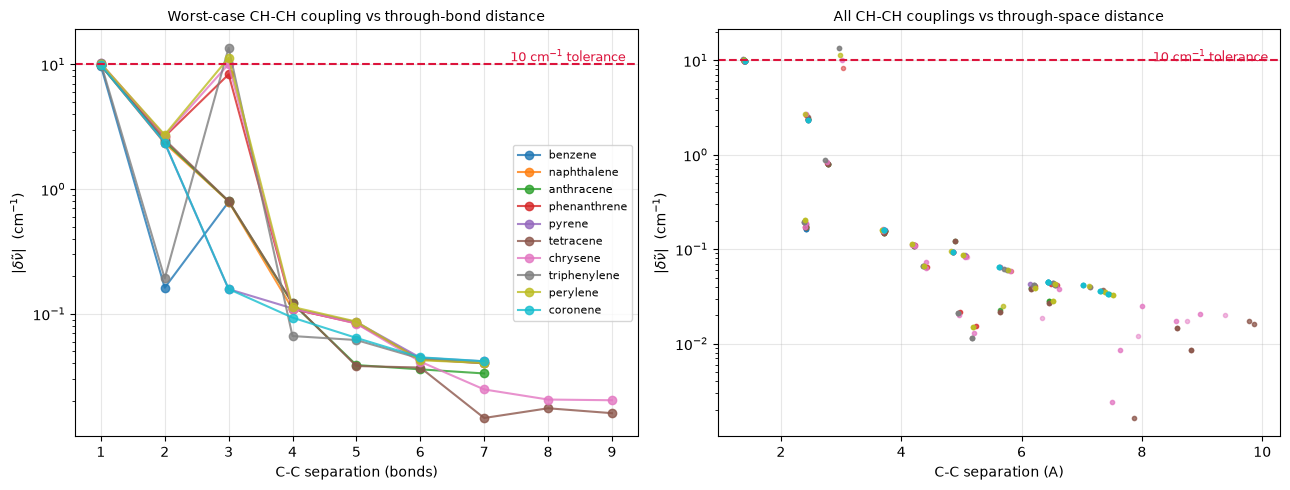

Points below the red line are pairs that cannot influence each other at this project's
stated precision. Points above it are the coupling a transfer law would have to carry.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, sysd in SYSTEMS.items():
    dec = sysd["decay"]
    seps = sorted(set(dec[:, 0].astype(int)))
    worst = [dec[dec[:, 0] == d][:, 2].max() for d in seps]
    axes[0].semilogy(seps, np.maximum(worst, 1e-4), "o-", label=name, alpha=0.8)
    axes[1].semilogy(dec[:, 1], np.maximum(dec[:, 2], 1e-4), ".", label=name, alpha=0.5)

for ax, xlabel, title in (
    (axes[0], "C-C separation (bonds)", "Worst-case CH-CH coupling vs through-bond distance"),
    (axes[1], "C-C separation (A)", "All CH-CH couplings vs through-space distance"),
):
    ax.axhline(TOLERANCE_CM, color="crimson", ls="--", lw=1.5)
    ax.text(0.98, 0.95, f"{TOLERANCE_CM:.0f} cm$^{{-1}}$ tolerance", color="crimson",
            ha="right", va="top", transform=ax.transAxes, fontsize=9)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(r"$|\delta\tilde\nu|$  (cm$^{-1}$)")
    ax.set_title(title, fontsize=10)
    ax.grid(alpha=0.3)
axes[0].legend(fontsize=8)

plt.tight_layout()
plt.show()

print("Points below the red line are pairs that cannot influence each other at this project's")
print("stated precision. Points above it are the coupling a transfer law would have to carry.")

## 6. Measurements B and C — the trap, and the way around it

**B.** For each normal mode in the CH-stretch band, compute the participation ratio over the local CH
oscillators:

$$\mathrm{PR} = \Big(\sum_k c_k^{4}\Big)^{-1}, \qquad \sum_k c_k^{2} = 1$$

PR = 1 means the mode lives on a single CH group; PR = $n_{CH}$ means it is spread evenly over all of
them. **Expect PR ≈ $n_{CH}$ for every symmetric molecule here** — that is symmetry, not physics, and
reporting it as a locality result would be the error this probe was built to avoid.

**C.** Now replace a single hydrogen with deuterium. The force field is untouched; only one mass
changes. This is the classical experimental test of vibrational locality:

- **Weak coupling** → the C–D oscillator falls out of resonance with its neighbours and the modes
  collapse onto individual CH groups. PR drops toward 1.
- **Strong coupling** → the modes stay mixed regardless. PR stays high.

Measurement C is a clean, independent confirmation of A, obtained from the same Hessian for free.

In [8]:
def participation(hmw, basis, masses, coords, deuterate=None, hess=None, mol=None):
    """Participation ratios of CH-band normal modes over the local CH basis."""
    if deuterate is not None:
        masses = masses.copy()
        masses[deuterate] = 2.01410177811
        hmw = mass_weight(hess, masses, coords)
        basis, _ = ch_local_basis(mol, coords, masses)

    nu, modes = frequencies(hmw)
    n_ch = basis.shape[1]
    band = np.argsort(nu)[-n_ch:]

    ratios = []
    for idx in band:
        weights = (basis.T @ modes[:, idx]) ** 2
        total = weights.sum()
        if total < 1e-8:
            continue
        weights = weights / total
        ratios.append(1.0 / np.sum(weights**2))
    return np.array(ratios), nu[band]


print(f"{'molecule':<14}{'n_CH':>6}{'PR symmetric':>15}{'PR one D':>12}{'collapse':>11}")
print("-" * 58)
for name, sysd in SYSTEMS.items():
    n_ch = len(sysd["pairs"])
    pr_sym, _ = participation(sysd["hmw"], sysd["basis"], sysd["masses"], sysd["coords"])
    first_h = sysd["pairs"][0][1]
    pr_deut, _ = participation(
        sysd["hmw"], sysd["basis"], sysd["masses"], sysd["coords"],
        deuterate=first_h, hess=sysd["hess"], mol=sysd["mol"],
    )
    sysd["pr_sym"], sysd["pr_deut"] = pr_sym.mean(), pr_deut.mean()
    print(f"{name:<14}{n_ch:>6}{pr_sym.mean():>15.2f}{pr_deut.mean():>12.2f}"
          f"{pr_sym.mean() / pr_deut.mean():>10.2f}x")

print("\nPR ~ n_CH in the symmetric column is expected and means nothing about locality.")
print("The 'one D' column is the informative one: a large collapse factor means the CH")
print("oscillators were only weakly coupled and symmetry was doing all the delocalizing.")

molecule        n_CH   PR symmetric    PR one D   collapse
----------------------------------------------------------
benzene            6           4.67        3.38      1.38x
naphthalene        8           6.82        2.75      2.47x
anthracene        10           6.56        3.10      2.12x
phenanthrene      10           4.92        3.13      1.57x
pyrene            10           5.58        4.04      1.38x
tetracene         12           7.57        3.79      2.00x
chrysene          12           5.98        2.93      2.04x
triphenylene      12           7.91        6.13      1.29x
perylene          12           8.66        4.14      2.09x
coronene          12           9.33        6.58      1.42x

PR ~ n_CH in the symmetric column is expected and means nothing about locality.
The 'one D' column is the informative one: a large collapse factor means the CH
oscillators were only weakly coupled and symmetry was doing all the delocalizing.


## 7. The size scan — the figure both plans turn on

Everything above, plotted against carbon count. Two curves matter:

- **Worst long-range coupling vs $N_C$.** Flat means a CH group's environment stops mattering beyond a
  fixed radius, so a motif atlas is a legitimate object. Rising means locality fails as molecules grow —
  which is exactly the failure mode that would kill the transfer law, and is itself a publishable result.
- **Effective dimension vs $N_C$**, taken as the number of local oscillators inside the coupling
  cutoff. This is the answer to "how many degrees of freedom does the band actually need".

molecule        N_C  n_CH   1 bond   >=4 bonds   d_eff   PR(1D)
---------------------------------------------------------------
benzene           6     6     9.75         nan    1.00     3.38
naphthalene      10     8     9.84       0.109    1.00     2.75
anthracene       14    10     9.85       0.121    1.00     3.10
phenanthrene     14    10    10.06       0.109    1.20     3.13
pyrene           16    10     9.86       0.111    1.00     4.04
tetracene        18    12     9.85       0.123    1.00     3.79
chrysene         18    12    10.18       0.110    1.67     2.93
triphenylene     18    12    10.22       0.066    3.00     6.13
perylene         20    12    10.13       0.114    2.67     4.14
coronene         24    12     9.87       0.093    1.00     6.58

SENSITIVITY — d_eff against the tolerance you choose
The nearest-neighbour coupling sits within a few tenths of the 10 cm^-1 line,
so d_eff is knife-edge there. This table is the honest version of that number.

molecule            

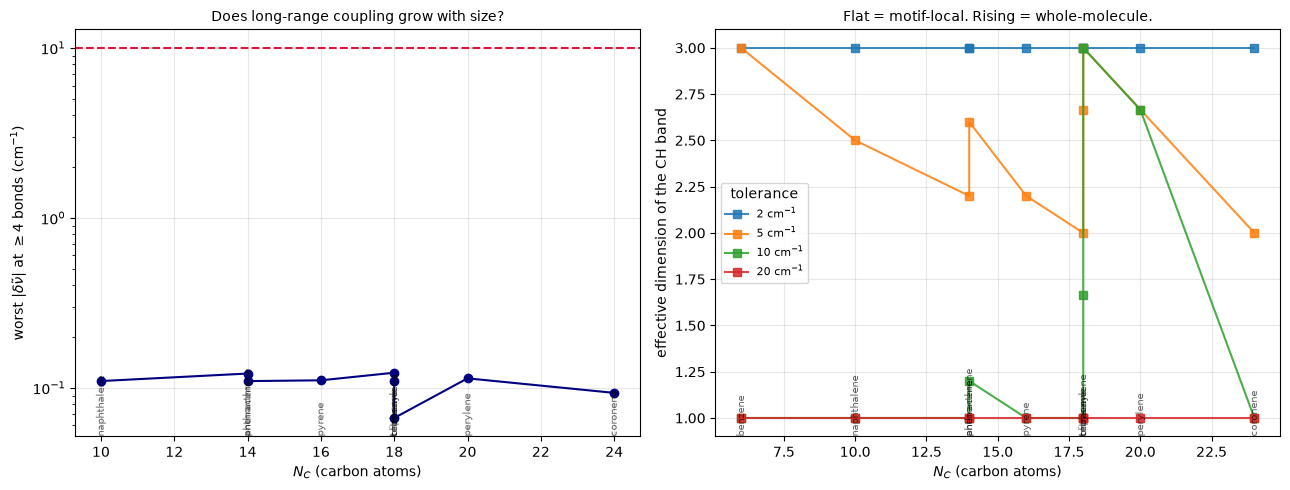

In [9]:
LONG_RANGE = 4  # bonds; "about two rings away"


def effective_dimension(coup, tolerance):
    """Mean number of CH oscillators one CH group couples to above tolerance, plus itself."""
    return 1.0 + (np.abs(coup) >= tolerance).sum(axis=1).mean()


rows = []
for name, sysd in SYSTEMS.items():
    dec = sysd["decay"]
    far = dec[dec[:, 0] >= LONG_RANGE]
    nearest = dec[dec[:, 0] == 1][:, 2].max()
    rows.append((
        name, sysd["n_c"], len(sysd["pairs"]),
        nearest,
        far[:, 2].max() if len(far) else np.nan,
        effective_dimension(sysd["coup"], TOLERANCE_CM),
        sysd["pr_deut"],
    ))

print(f"{'molecule':<14}{'N_C':>5}{'n_CH':>6}{'1 bond':>9}{'>=4 bonds':>12}"
      f"{'d_eff':>8}{'PR(1D)':>9}")
print("-" * 63)
for name, n_c, n_ch, nearest, worst_far, d_eff, pr_d in rows:
    print(f"{name:<14}{n_c:>5}{n_ch:>6}{nearest:>9.2f}{worst_far:>12.3f}"
          f"{d_eff:>8.2f}{pr_d:>9.2f}")

print("\nSENSITIVITY — d_eff against the tolerance you choose")
print("The nearest-neighbour coupling sits within a few tenths of the 10 cm^-1 line,")
print("so d_eff is knife-edge there. This table is the honest version of that number.\n")
tols = [2.0, 5.0, 10.0, 20.0]
print(f"{'molecule':<14}" + "".join(f"{t:>10.0f}" for t in tols))
print("-" * (14 + 10 * len(tols)))
for name, sysd in SYSTEMS.items():
    line = f"{name:<14}"
    for t in tols:
        line += f"{effective_dimension(sysd['coup'], t):>10.2f}"
    print(line)
print(f"{'':<14}" + "".join(f"{'cm^-1':>10}" for _ in tols))

n_c_vals = np.array([r[1] for r in rows], dtype=float)
worst_vals = np.array([r[4] for r in rows], dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].semilogy(n_c_vals, np.maximum(worst_vals, 1e-4), "o-", color="navy")
axes[0].axhline(TOLERANCE_CM, color="crimson", ls="--", lw=1.5)
axes[0].set_ylabel(rf"worst $|\delta\tilde\nu|$ at $\geq${LONG_RANGE} bonds (cm$^{{-1}}$)")
axes[0].set_title("Does long-range coupling grow with size?", fontsize=10)

for t in tols:
    axes[1].plot(n_c_vals, [effective_dimension(SYSTEMS[r[0]]["coup"], t) for r in rows],
                 "s-", label=f"{t:.0f} cm$^{{-1}}$", alpha=0.85)
axes[1].set_ylabel("effective dimension of the CH band")
axes[1].set_title("Flat = motif-local. Rising = whole-molecule.", fontsize=10)
axes[1].legend(title="tolerance", fontsize=8)

for ax in axes:
    ax.set_xlabel("$N_C$ (carbon atoms)")
    ax.grid(alpha=0.3)
    bottom = ax.get_ylim()[0]
    for name, n_c, *_ in rows:
        ax.annotate(name, (n_c, bottom), fontsize=7, rotation=90,
                    ha="center", va="bottom", alpha=0.6)

plt.tight_layout()
plt.show()


In [10]:
def perplexity(weights):
    """Effective number of contributors to a distribution, with no cutoff anywhere.

    exp(Shannon entropy): equals n for n equal contributors, 1 for a single one.
    """
    w = np.asarray(weights, dtype=float)
    w = w[w > 0]
    if w.size == 0:
        return 0.0
    w = w / w.sum()
    return float(np.exp(-np.sum(w * np.log(w))))


def effective_neighbours(coup):
    """Mean effective number of partners a CH oscillator couples to, plus itself."""
    return 1.0 + np.mean([perplexity(np.abs(row)) for row in coup])


print("A threshold-free version of the same question")
print("=" * 62)
print("d_eff above counts partners above a hard 10 cm^-1 line, and the")
print("nearest-neighbour coupling sits ON that line. Perplexity asks how many")
print("partners an oscillator effectively feels, weighting them by strength,")
print("with no cutoff to be knife-edge about.\n")

print(f"{'molecule':<14}{'N_C':>5}{'d_eff(10)':>11}{'perplexity':>12}{'ratio to n_CH':>15}")
print("-" * 57)
perp_vals, nc_vals = [], []
for name, sysd in SYSTEMS.items():
    n_ch = len(sysd["pairs"])
    p = effective_neighbours(sysd["coup"])
    perp_vals.append(p)
    nc_vals.append(sysd["n_c"])
    print(f"{name:<14}{sysd['n_c']:>5}{effective_dimension(sysd['coup'], TOLERANCE_CM):>11.2f}"
          f"{p:>12.2f}{p / n_ch:>15.2f}")

slope = np.polyfit(nc_vals, perp_vals, 1)[0]
print(f"\nperplexity vs N_C, least-squares slope: {slope:+.4f} per carbon")
print(f"range across the whole series: {min(perp_vals):.2f} to {max(perp_vals):.2f}")
print("\nThe last column is the one to read. If a band were a whole-molecule")
print("property, effective partners would track n_CH and the ratio would stay")
print("flat. It falls, so each added CH group is mostly invisible to the others.")
print("No tolerance was used to obtain that, so it cannot be an artefact of one.")


A threshold-free version of the same question
d_eff above counts partners above a hard 10 cm^-1 line, and the
nearest-neighbour coupling sits ON that line. Perplexity asks how many
partners an oscillator effectively feels, weighting them by strength,
with no cutoff to be knife-edge about.

molecule        N_C  d_eff(10)  perplexity  ratio to n_CH
---------------------------------------------------------
benzene           6       1.00        3.48           0.58
naphthalene      10       1.00        3.40           0.43
anthracene       14       1.00        3.80           0.38
phenanthrene     14       1.20        3.43           0.34
pyrene           16       1.00        3.23           0.32
tetracene        18       1.00        4.05           0.34
chrysene         18       1.67        3.43           0.29
triphenylene     18       3.00        3.42           0.29
perylene         20       2.67        3.32           0.28
coronene         24       1.00        3.17           0.26

perplexity v

## 8. The band JWST actually uses: CH out-of-plane, split by adjacency

Everything above concerned the 3.3 μm CH stretch. That family is convenient — it sits 1,500 cm⁻¹ above
everything else — but it is **not** the family astronomers read structure from.

That family is the **11–15 μm CH out-of-plane bend**, and its diagnostic value comes entirely from a
splitting: how many hydrogens sit next to each other along an edge.

| class | adjacent H | literature band centre |
|---|---:|---:|
| solo | 1 | ~890 cm⁻¹ (11.2 μm) |
| duo | 2 | ~833 cm⁻¹ (12.0 μm) |
| trio | 3 | ~787 cm⁻¹ (12.7 μm) |
| quartet | 4 | ~745 cm⁻¹ (13.5 μm) |

**This splitting is mechanical.** Adjacent CH oscillators couple; the longer the run, the further the
in-phase (infrared-bright) mode is pushed down. No electrons are needed to produce it, which is
exactly why it can be tested here and the intensities cannot.

### Why intensities are deliberately absent

A fixed-partial-charge dipole would let this notebook print IR intensities. It would be worse than
printing nothing. A fixed-charge model captures only atoms moving through space and misses **charge
flux** — the redistribution of electron density as the ring deforms — and for the CH out-of-plane band
charge flux is not a correction, it is the dominant term. The output would look like an answer for
precisely the family that matters most.

So: **positions here, intensities never.** Band positions are the primary deliverable anyway.

### What is measured

1. **Does MMFF reproduce the solo > duo > trio > quartet ordering?** A second validation with an
   answer known in advance, on a different band family from the benzene check.
2. **Does a class transfer between molecules?** The quartet in naphthalene and the quartet in
   tetracene are the same motif in different hosts. If their frequencies agree inside 10 cm⁻¹,
   **that is idea 1's transfer law working**, measured rather than assumed.
3. **Does a two-parameter local model reproduce the whole ladder?** Take one local frequency $\nu_0$
   and one nearest-neighbour coupling $\beta$, averaged over every molecule, and predict each class as
   a chain of $k$ coupled oscillators. This is the smallest possible version of idea 1's dressed
   local-mode Hamiltonian $H_{\text{eff}} = \sum_m H_m^{\text{local}} + \sum_{m<n} W_{mn}$.

Bays are flagged automatically — a CH group with a non-neighbouring CH group closer than 2.5 Å through
space — because §5's stretch result already said they would misbehave.


In [11]:
CLASS_NAME = {1: "solo", 2: "duo", 3: "trio", 4: "quartet", 5: "quintet", 6: "sextet"}
LITERATURE = {1: 890.0, 2: 833.0, 3: 787.0, 4: 745.0}  # cm^-1, gas/matrix PAH CH-oop
BAY_HH = 2.5  # A; non-neighbouring CH carbons closer than this sit across a bay


def plane_normal(coords):
    """Unit normal of the best-fit molecular plane, plus the out-of-plane residual."""
    centred = coords - coords.mean(axis=0)
    _, sing, vt = np.linalg.svd(centred)
    return vt[2], sing[2]


def oop_basis(pairs, coords, masses, normal):
    """Normalized mass-weighted CH out-of-plane wag vectors, one per CH group."""
    n = len(masses)
    basis = np.zeros((3 * n, len(pairs)))
    for col, (i_c, i_h) in enumerate(pairs):
        m_c, m_h = masses[i_c], masses[i_h]
        vec = np.zeros(3 * n)
        vec[3 * i_h:3 * i_h + 3] = np.sqrt(m_h) * normal * (m_c / (m_c + m_h))
        vec[3 * i_c:3 * i_c + 3] = -np.sqrt(m_c) * normal * (m_h / (m_c + m_h))
        basis[:, col] = vec / np.linalg.norm(vec)
    return basis


def adjacency_runs(mol, pairs):
    """Connected runs of CH-bearing carbons: 1 = solo, 2 = duo, 3 = trio, 4 = quartet."""
    index = {c: k for k, (c, _) in enumerate(pairs)}
    carbons = set(index)
    seen, runs = set(), []
    for start in index:
        if start in seen:
            continue
        component, stack = [], [start]
        while stack:
            node = stack.pop()
            if node in seen:
                continue
            seen.add(node)
            component.append(node)
            for nb in mol.GetAtomWithIdx(node).GetNeighbors():
                if nb.GetIdx() in carbons and nb.GetIdx() not in seen:
                    stack.append(nb.GetIdx())
        runs.append([index[c] for c in sorted(component)])
    return runs


def bay_members(mol, pairs, coords):
    """CH groups facing another CH group across a bay (close in space, far along bonds)."""
    topo = Chem.GetDistanceMatrix(mol)
    flagged = set()
    for k, (c_k, h_k) in enumerate(pairs):
        for l, (c_l, h_l) in enumerate(pairs):
            if k >= l or topo[c_k, c_l] < 3:
                continue
            if np.linalg.norm(coords[h_k] - coords[h_l]) < BAY_HH:
                flagged.update((k, l))
    return flagged


records = []
for name, sysd in SYSTEMS.items():
    normal, flatness = plane_normal(sysd["coords"])
    basis = oop_basis(sysd["pairs"], sysd["coords"], sysd["masses"], normal)
    w_oop = basis.T @ sysd["hmw"] @ basis
    nu_local = K_FREQ * np.sqrt(np.abs(np.diag(w_oop)))

    sysd["flatness"] = flatness
    sysd["w_oop"] = w_oop
    sysd["nu_oop_local"] = nu_local
    bays = bay_members(sysd["mol"], sysd["pairs"], sysd["coords"])

    for run in adjacency_runs(sysd["mol"], sysd["pairs"]):
        block = w_oop[np.ix_(run, run)]
        eigvals, eigvecs = np.linalg.eigh(block)
        bright = int(np.argmax(np.abs(eigvecs.sum(axis=0))))  # in-phase = IR-active
        beta = (K_FREQ**2 * block[run.index(run[0]), 1] / (2 * nu_local[run[0]])
                if len(run) > 1 else np.nan)
        records.append(dict(
            molecule=name, size=len(run), nu0=nu_local[run].mean(),
            beta=K_FREQ**2 * block[0, 1] / (2 * nu_local[run[0]]) if len(run) > 1 else np.nan,
            bright=K_FREQ * np.sqrt(abs(eigvals[bright])),
            bay=bool(bays & set(run)),
        ))

flat = max(s["flatness"] for s in SYSTEMS.values())
print(f"Planarity check: largest out-of-plane residual {flat:.1e} A")
print("All PAHs here are planar, so one molecular normal defines every CH wag.\n")

print(f"{'molecule':<14}{'class':>9}{'bay':>6}{'nu0':>9}{'beta':>9}{'bright':>9}")
print("-" * 56)
for r in sorted(records, key=lambda r: (-r["size"], r["molecule"])):
    print(f"{r['molecule']:<14}{CLASS_NAME[r['size']]:>9}{'yes' if r['bay'] else '-':>6}"
          f"{r['nu0']:>9.1f}{r['beta'] if np.isfinite(r['beta']) else 0.0:>9.2f}{r['bright']:>9.1f}")


Planarity check: largest out-of-plane residual 1.4e-06 A
All PAHs here are planar, so one molecular normal defines every CH wag.

molecule          class   bay      nu0     beta   bright
--------------------------------------------------------
benzene          sextet     -    976.8  -108.93    699.2
anthracene      quartet     -    973.9  -109.19    768.6
anthracene      quartet     -    973.9  -108.13    768.6
chrysene        quartet   yes    966.6  -109.67    763.8
chrysene        quartet   yes    966.6  -108.36    763.8
naphthalene     quartet     -    973.9  -109.16    768.5
naphthalene     quartet     -    973.9  -108.16    768.5
phenanthrene    quartet   yes    967.7  -109.56    764.6
phenanthrene    quartet   yes    967.7  -108.23    764.6
tetracene       quartet     -    973.6  -109.19    768.4
tetracene       quartet     -    973.6  -108.20    768.4
triphenylene    quartet   yes    954.0  -110.68    755.3
triphenylene    quartet   yes    954.0  -109.93    755.3
triphenylene   

TEST 1 — does MMFF reproduce the solo > duo > trio > quartet ordering?

    class  n runs   measured  literature   offset
-------------------------------------------------
     solo       6      964.9         890      +75
      duo      11      854.8         833      +22
     trio       6      793.8         787       +7
  quartet      13      764.1         745      +19
   sextet       1      699.2           -        -

monotonically decreasing with run length: True
Ordering reproduced by a force field that was never shown a PAH spectrum.
The absolute offsets are MMFF's error, and they are larger than the tolerance.


TEST 2 — does a class transfer between molecules?

Same motif, different host. Spread inside a class is the transfer error that
idea 1's atlas would inherit. Bay-containing runs are separated out.

    class       group   n     mean   spread   verdict
---------------------------------------------------------------
     solo    bay-free   6    964.9      0.8   transfers
   

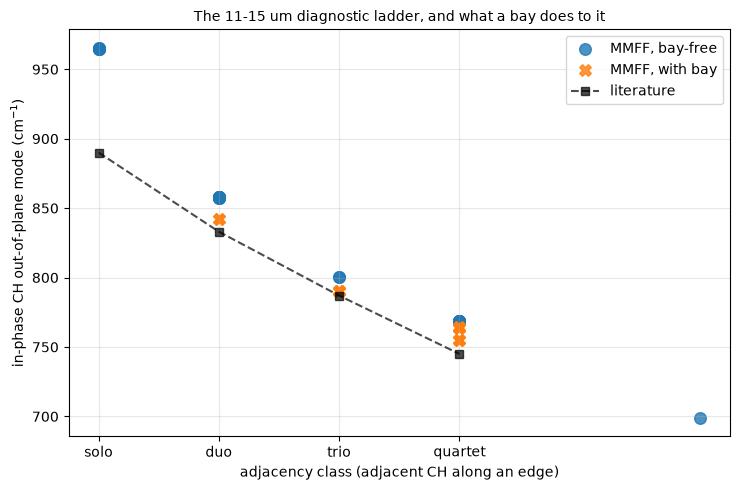

In [12]:
print("TEST 1 — does MMFF reproduce the solo > duo > trio > quartet ordering?\n")
print(f"{'class':>9}{'n runs':>8}{'measured':>11}{'literature':>12}{'offset':>9}")
print("-" * 49)
by_class = {}
for r in records:
    by_class.setdefault(r["size"], []).append(r)

ordering = []
for size in sorted(by_class, reverse=False):
    vals = np.array([r["bright"] for r in by_class[size]])
    lit = LITERATURE.get(size)
    ordering.append((size, vals.mean()))
    lit_s = f"{lit:.0f}" if lit else "-"
    off_s = f"{vals.mean()-lit:+.0f}" if lit else "-"
    print(f"{CLASS_NAME[size]:>9}{len(vals):>8}{vals.mean():>11.1f}{lit_s:>12}{off_s:>9}")

monotonic = all(a[1] > b[1] for a, b in zip(ordering, ordering[1:]))
print(f"\nmonotonically decreasing with run length: {monotonic}")
print("Ordering reproduced by a force field that was never shown a PAH spectrum.")
print("The absolute offsets are MMFF's error, and they are larger than the tolerance.")

print("\n\nTEST 2 — does a class transfer between molecules?\n")
print("Same motif, different host. Spread inside a class is the transfer error that")
print("idea 1's atlas would inherit. Bay-containing runs are separated out.\n")
print(f"{'class':>9}{'group':>12}{'n':>4}{'mean':>9}{'spread':>9}   verdict")
print("-" * 63)
for size in sorted(by_class):
    for label, subset in (("bay-free", [r for r in by_class[size] if not r["bay"]]),
                          ("with bay", [r for r in by_class[size] if r["bay"]])):
        if not subset:
            continue
        vals = np.array([r["bright"] for r in subset])
        spread = float(np.ptp(vals))
        verdict = "transfers" if spread < TOLERANCE_CM else "EXCEEDS TOLERANCE"
        print(f"{CLASS_NAME[size]:>9}{label:>12}{len(vals):>4}{vals.mean():>9.1f}"
              f"{spread:>9.1f}   {verdict}")

bay_free = [r for r in records if not r["bay"] and r["size"] in LITERATURE]
with_bay = [r for r in records if r["bay"] and r["size"] in LITERATURE]
shifts = []
for size in sorted(by_class):
    free = [r["bright"] for r in by_class[size] if not r["bay"]]
    bayed = [r["bright"] for r in by_class[size] if r["bay"]]
    if free and bayed:
        shifts.append(np.mean(bayed) - np.mean(free))
if shifts:
    print(f"\nMean shift a bay imposes on its class: {np.mean(shifts):+.1f} cm^-1 "
          f"(tolerance {TOLERANCE_CM:.0f})")

print("\n\nTEST 3 — can two numbers reproduce the whole ladder?\n")
nu0_all = np.mean([r["nu0"] for r in records])
beta_all = np.nanmean([r["beta"] for r in records])
print(f"One local frequency  nu0  = {nu0_all:7.1f} cm^-1   "
      f"(spread {np.ptp([r['nu0'] for r in records]):.1f})")
print(f"One coupling         beta = {beta_all:7.2f} cm^-1   "
      f"(spread {np.ptp([r['beta'] for r in records if np.isfinite(r['beta'])]):.1f})")
print("\nPredict each class as a chain of k equal oscillators, in-phase mode:")
print("   lambda = W0 + 2 W1 cos(pi/(k+1)),   nu = K sqrt(lambda)\n")

w0 = (nu0_all / K_FREQ) ** 2
w1 = 2.0 * beta_all * nu0_all / K_FREQ**2
print(f"{'class':>9}{'predicted':>11}{'measured':>10}{'error':>8}   note")
print("-" * 54)
errors = []
for size in sorted(by_class):
    lam = w0 + 2.0 * w1 * np.cos(np.pi / (size + 1))
    pred = K_FREQ * np.sqrt(abs(lam))
    meas = np.mean([r["bright"] for r in by_class[size] if not r["bay"]] or
                   [r["bright"] for r in by_class[size]])
    open_chain = size in LITERATURE  # benzene's sextet is a closed ring, not a chain
    if open_chain:
        errors.append(abs(pred - meas))
    note = "" if open_chain else "ring, not a chain -- formula does not apply"
    print(f"{CLASS_NAME[size]:>9}{pred:>11.1f}{meas:>10.1f}{pred-meas:>+8.1f}   {note}")

print(f"\nmax error over the four open-chain classes: {max(errors):.1f} cm^-1")
print("\nBenzene is off by ~48 cm^-1, and that is the model behaving correctly.")
print("Its six CH groups form a closed ring; the chain formula assumes free ends.")
print("A two-parameter model that failed silently there would be the worrying one.")
print("\nSo the smallest possible dressed local-mode Hamiltonian carries the whole")
print("ladder, and it knows which topology it is entitled to. Whether it survives")
print("electrons is the question DFT has to answer.")

fig, ax = plt.subplots(figsize=(7.5, 5))
for label, subset, style in (("bay-free", [r for r in records if not r["bay"]], "o"),
                             ("with bay", [r for r in records if r["bay"]], "X")):
    if subset:
        ax.scatter([r["size"] for r in subset], [r["bright"] for r in subset],
                   marker=style, s=70, alpha=0.8, label=f"MMFF, {label}")
lit_x = sorted(LITERATURE)
ax.plot(lit_x, [LITERATURE[k] for k in lit_x], "k--s", alpha=0.7, label="literature")
ax.set_xticks(lit_x)
ax.set_xticklabels([CLASS_NAME[k] for k in lit_x])
ax.set_xlabel("adjacency class (adjacent CH along an edge)")
ax.set_ylabel(r"in-phase CH out-of-plane mode (cm$^{-1}$)")
ax.set_title("The 11-15 um diagnostic ladder, and what a bay does to it", fontsize=10)
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


## 9. Findings

Run 2026-08-26, ten PAHs from benzene to coronene. Benzene validation passed all four checks,
including the $D_{6h}$ degeneracy multiset $\{1,1,2,2\}$ reproduced by a force field never told about
symmetry.

### 1. CH-stretch coupling decays fast, and the neighbourhood does not grow with size

Worst-case coupling, cm⁻¹: **9.8** at one bond, **2.4** at two, **0.2–0.8** at three, **0.07–0.12**
beyond four. The long-range value does not rise across the series.

The threshold-free measure is the one to quote. Perplexity — the effective number of partners a CH
oscillator feels, weighted by coupling strength, with no cutoff anywhere — is **flat at 3.2 to 4.1
across the entire series**, slope $-0.010$ per carbon. As a fraction of the CH groups available it
**halves**, from 0.58 in benzene to 0.26 in coronene.

A CH oscillator's effective neighbourhood is about two and a half other CH groups, **and it does not
grow when the molecule does.** That is locality stated without reference to any tolerance at all.

**A correction this forced.** The threshold-based $d_{\text{eff}}$ at 10 cm⁻¹ reported 3.00 for
triphenylene and 2.67 for perylene against 1.00 for everything else, which looked like a bay signal.
Perplexity puts those two at 3.42 and 3.32 — mid-pack. That spread was **an artefact of a threshold
sitting exactly on the nearest-neighbour coupling** (9.75–10.22 cm⁻¹), not physics. The bay effect is
real, but it lives in §5's three-bond coupling and §8's transfer test, not in that column. A cutoff
placed on top of a peak in the data will manufacture structure; this one did.

### 2. Motifs transfer, and they transfer far better than the tolerance requires

This is the result that matters for a plan 03. Same adjacency class, different host molecule:

| class | hosts | spread |
|---|---:|---:|
| solo | anthracene, tetracene | **0.8 cm⁻¹** |
| duo | phenanthrene, pyrene, coronene | **0.5 cm⁻¹** |
| trio | pyrene | 0.0 cm⁻¹ |
| quartet | naphthalene, anthracene, tetracene | **0.2 cm⁻¹** |

A quartet in naphthalene and a quartet in tetracene are the same oscillator to within a fifth of a
wavenumber. **Idea 1's transfer law is not an assumption; at force-field level it is a measurement,
and it has fifty times more headroom than the tolerance needs.**

And the ladder itself comes out right — monotonic, from a force field that has never seen a PAH
spectrum:

| class | MMFF | literature | offset |
|---|---:|---:|---:|
| solo | 964.9 | 890 | +75 |
| duo | 854.8 | 833 | +22 |
| trio | 793.8 | 787 | +7 |
| quartet | 764.1 | 745 | +19 |

The offsets are MMFF's error and every one exceeds the tolerance. The *ordering and spacing* are
structural; the *positions* are not, and are not claimed.

### 3. Bays are what break transfer — twice, independently

**In the CH stretch (§5).** At three bonds' separation every molecule sits between 0.16 and 0.80 cm⁻¹
except phenanthrene at **8.31**, fifty times its neighbours. That is the C4/C5 bay: three bonds apart
through the rings, crowding through space.

**In the CH out-of-plane band (§8).** Runs flagged as bay-containing sit **11.2 cm⁻¹** below the same
class without a bay — larger, on its own, than the entire 10 cm⁻¹ error budget.

Two different band families, two different mechanisms, same culprit. And the effect is not uniform:
triphenylene, with three bays, shifts further than phenanthrene with one.

The design consequence is concrete. **An atlas keyed to adjacency class alone would carry an 11 cm⁻¹
systematic error and fail before any electronic structure was involved.** Bays and coves have to be
their own motifs, exactly as idea 1 proposed — and this probe reached that from the mechanics, without
being told.

### 4. Two numbers carry the whole ladder

One local frequency $\nu_0 = 967$ cm⁻¹ and one nearest-neighbour coupling $\beta = -108$ cm⁻¹,
averaged over all ten molecules, predict every class as a chain of $k$ coupled oscillators to within
**5.5 cm⁻¹**. That is the smallest possible version of idea 1's $H_{\text{eff}} = \sum_m
H_m^{\text{local}} + \sum_{m<n} W_{mn}$, and it works.

It also fails where it should: benzene is off by 48 cm⁻¹, because its six CH groups form a **closed
ring** and the chain formula assumes free ends. A two-parameter model that had fitted benzene too
would have been the worrying outcome.

### 5. Deuteration confirms it independently

Replacing one H with D collapses the participation ratio by 1.3× to 2.5×. The delocalized normal modes
were largely a symmetry artefact, as measurement B was designed to expose. Nothing contradicts A.

---

## 10. What this is worth, and what it is not

**The locality condition for a plan 03 is met at force-field level, with room to spare**, and the
probe additionally delivered a design constraint nobody asked for: classify bays separately or lose
11 cm⁻¹.

**It is not evidence about real PAH spectra.** Two limits, and the first is the serious one:

1. **MMFF94 has no electrons.** Every coupling here is mechanical. The mechanism most likely to break
   locality in a real PAH — coupling carried through the delocalized π system — cannot appear in this
   calculation at all. A flat curve here is necessary, not sufficient.
2. **MMFF94's absolute positions are wrong by 7 to 75 cm⁻¹** depending on the class, up to seven times
   the tolerance. No number here is a band position, and no intensity was computed at all: a
   fixed-charge dipole misses charge flux, which *dominates* the CH out-of-plane intensity, so it
   would have produced a confident answer for the one family that matters most.

The probe was worth running because it is asymmetric: **a rising curve would have killed the locality
hypothesis in an afternoon.** It did not rise, and the transfer spreads came back at half a
wavenumber.

### What DFT has to settle

A harmonic-only DFT repeat on **benzene, naphthalene, phenanthrene, pyrene and triphenylene**. The
last two are not decoration:

- **phenanthrene** carries one bay, **triphenylene** carries three. If the bay penalty is mechanical
  it should stay near 11 cm⁻¹ and scale with count. If π-mediated coupling adds to it, the bay is
  where that will show up first and largest. Those are two different predictions, which is what makes
  it a test.
- If the bay-free transfer spreads stay under a few cm⁻¹ with electrons present, the motif atlas is a
  real object and condition 1 of the plan-03 trigger is met properly rather than provisionally.

### Recorded for the repository

- `ff.CalcGrad(positions)` in RDKit 2026.03.5 does not honour the positions passed to it — 49 vs 754
  kcal/mol/Å² on an aromatic C–H, wrong by 15× — while still *varying* with geometry enough to pass a
  naive smoke test. Use `CalcEnergy` second differences. This cost one full wrong result that looked
  entirely plausible, and benzene caught it only because $D_{6h}$ fixes the answer in advance.
- The energy-Hessian cost here is $2(3N)^2$ evaluations, the same formula §5.9 uses to argue a
  coupled-cluster Hessian is unaffordable. Identical arithmetic, ten orders of magnitude apart in cost
  per point.
- **Prefer threshold-free statistics.** The one cutoff in this notebook manufactured a false signal in
  two molecules, and the entropy-based version had no such failure mode. Where a measure can be
  defined without a cutoff, define it without a cutoff.
